In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
from tqdm import tqdm

n = 5
mechanisms = ['MCAR', 'MAR_l', 'MAR_m', 'MAR_h', 'MNAR_l', 'MNAR_m', 'MNAR_h']

mec_labels = {}
for mec in mechanisms:
    if "_" in mec:
        base, sub = mec.split("_")
        mec_label = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_label = mec
    mec_labels[mec] = mec_label


mr_values = ["05", "10", "15", "20", "25"]

metric_names = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
metric_labels = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1': 'F1-Score'
}
colors = {
    'MCAR':   (0.25, 0.85, 0.35),   # verde vibrante
    'MAR_l':  (1.00, 0.70, 0.30),   # laranja claro
    'MAR_m':  (0.95, 0.50, 0.15),   # laranja médio
    'MAR_h':  (0.80, 0.30, 0.05),   # laranja escuro
    'MNAR_l': (0.45, 0.70, 1.00),   # azul claro
    'MNAR_m': (0.25, 0.50, 0.95),   # azul médio
    'MNAR_h': (0.10, 0.35, 0.85),   # azul escuro
}
EXCLUDED_PATIENTS = ['AJ7TSV9','AS2MVDL']
markers = {'MCAR': 'o', 'MAR_l': 's', 'MAR_m': 'D', 'MAR_h': '^', 'MNAR_l': 'X', 'MNAR_m': 'P', 'MNAR_h': 'H'}

order = ['ATHKM6V', 'AUY8KYW', 'AURCTAK', 'AX6281V', 'AOYM4KG', 'A4G0044', 'A7EM0B6', 'AQC0L71', 'AZIK4ZA', 'AHYIJDV', 'AAXAA7Z', 'A1ZJ41O', 'AFPB8J2', 'ASFODQR', 'A0VFT1N', 'AJWW3IY', 'AV2GF3B', 'AKXN5ZZ', 'A1K5DRI', 'A4E0D03', 'APGIB2T', 'A3OU183', 'AYWIEKR', 'A0NVTRV', 'AIFDJZB', 'A36HR6Y', 'AA2KP1S', 'AJMQUVV', 'AMV7EQF', 'AYEFCWQ']



In [2]:
patients = {}
for metric in ['RHR', 'HROS']:
    patients[metric] = [patient for patient in os.listdir(f"Patients/{metric}")
                        if os.path.isdir(os.path.join(f"Patients/{metric}", patient)) and patient not in EXCLUDED_PATIENTS]

tuples_count = {}
for metric, patient_list in patients.items():
    tuples_count[metric] = {}
    for patient in patient_list:
        try:
            df_full = pd.read_csv(f'Patients/{metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
            tuples_count[metric][patient] = len(df_full)
        except (FileNotFoundError, pd.errors.EmptyDataError):
            print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
            tuples_count[metric][patient] = 0
            patients[metric].remove(patient)

            # Concatenate tuples_count into a single DataFrame with a 'metric' column

df_tuples = pd.concat(
    [
        pd.DataFrame({
            'patient': list(p_dict.keys()),
            'tuples_count': list(p_dict.values()),
            'metric': metric
        })
        for metric, p_dict in tuples_count.items()
    ],
    ignore_index=True
)

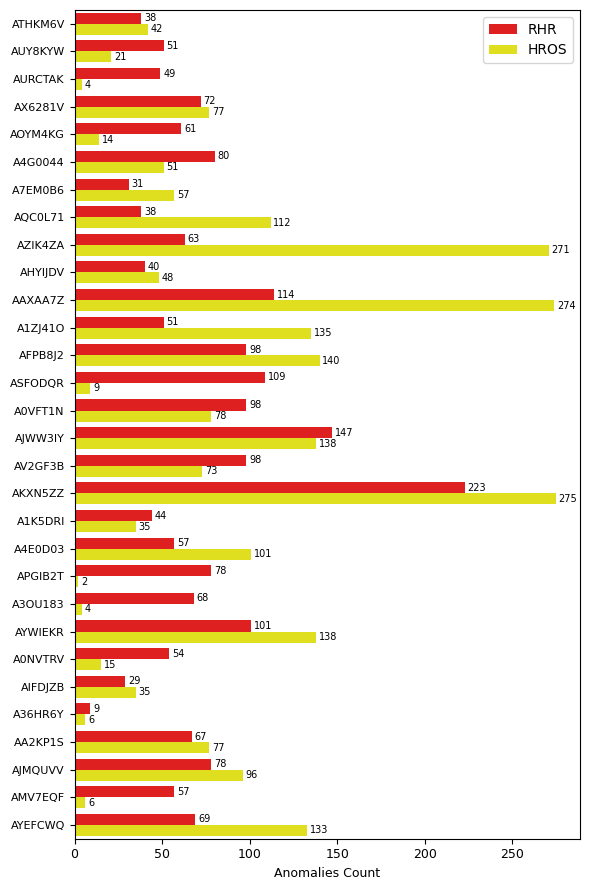

In [3]:
plt.figure(figsize=(6, 9))
palette = {'RHR': 'red', 'HROS': 'yellow'}
ax = sns.barplot(y="patient", x="tuples_count", hue="metric", data=df_tuples, palette=palette, orient="h", order=order)
ax.bar_label(ax.containers[0], fontsize=7, padding=2)
ax.bar_label(ax.containers[1], fontsize=7, padding=2)
plt.ylabel('')
plt.xlabel('Anomalies Count', fontsize=9)
plt.xticks(fontsize=9)
plt.title('')
plt.yticks(fontsize=8)  # Mantém os nomes dos pacientes legíveis
plt.legend(title='')
plt.tight_layout()
#plt.savefig('Plots/original_counts.png', dpi=300)
plt.show()

In [81]:
class ConfusionMatrix:

    metrics_table_mec = {mec: pd.DataFrame(columns=['MR', 'Accuracy', 'Precision', 'Recall', 'F1_Score']) 
            for mec in mechanisms}

    def __init__(self, metric):
        self.metric = metric
        self.patients = [patient for patient in os.listdir(f"Patients/{self.metric}") 
                         if os.path.isdir(os.path.join(f"Patients/{self.metric}", patient)) and patient not in EXCLUDED_PATIENTS]
        #self._plot_og_anomalies()
        self._metrics_df()

    def _intervals_overlap(self, a, b):
        """Verifica se os intervalos a e b se sobrepõem"""
        return max(a[0], b[0]) <= min(a[1], b[1])

    def _match_event_intervals(self, y_true, y_pred):
        """
        Compara listas de intervalos (eventos reais e previstos).
        Cada intervalo é uma tupla: (inicio, fim)

        Retorna TP, FP, FN
        """
        matched = set()

        for i, pred in enumerate(y_pred):
            for j, true in enumerate(y_true):
                if self._intervals_overlap(pred, true):
                    matched.add(j)
                    break  # conta só uma correspondência

        TP = len(matched)
        FP = len(y_pred) - TP
        FN = len(y_true) - TP

        return TP, FP, FN 
    
    # Iterar sobre os pacientes e contar as tuplas no dataset completo (df_full)
    def _plot_og_anomalies(self):
        tuples_count = {}
        for patient in self.patients:
            if patient in EXCLUDED_PATIENTS:
                continue
            try:
                df_full = pd.read_csv(f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv', usecols=[1, 2], header=None)
                tuples_count[patient] = len(df_full)
            except (FileNotFoundError, pd.errors.EmptyDataError):
                print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                tuples_count[patient] = 0
                self.patients.remove(patient)

        # Plotar os resultados
        plt.figure(figsize=(15, 6))
        plt.bar(tuples_count.keys(), tuples_count.values(), color='skyblue')
        plt.xlabel('Pacientes')
        plt.ylabel('Quantidade de Tuplas')
        plt.title('Quantidade de Tuplas nos Datasets de Todos os Pacientes')
        plt.xticks(rotation=45)
        # Adicionar os valores absolutos acima de cada barra
        for i, (patient, count) in enumerate(tuples_count.items()):
            plt.text(i, count + 1, str(count), ha='center', va='bottom', fontsize=8)
        plt.show()

    def _metrics_df(self):

        print(f"Calculando métricas para {self.metric}...")

        for mec in mechanisms:

            results = {}

            # Agora absolute separado por i
            absolute = {i: {} for i in range(1, n + 1)}

            for patient in tqdm(self.patients, desc=f"Processando pacientes para {mec}"):

                # Carregar df_full
                try:
                    df_full = pd.read_csv(
                        f'Patients/{self.metric}/{patient}/Anomalies/{patient}_original_anomalies.csv',
                        header=None
                    )
                except (FileNotFoundError, pd.errors.EmptyDataError):
                    print(f"Arquivo completo não encontrado ou vazio para o paciente {patient}. Pulando...")
                    continue

                # Inicializar dfs_miss
                dfs_miss = {}
                for mr_value in mr_values:
                    dfs_miss[mr_value] = {}
                    for i in range(1, n + 1):
                        file_path = f'Patients/{self.metric}/{patient}/Anomalies/{mec}/{i}/{patient}_anomalies_{mec}_{i}_{mr_value}.csv'

                        if os.path.exists(file_path) and os.path.getsize(file_path) > 0:
                            dfs_miss[mr_value][i] = pd.read_csv(file_path, usecols=[1, 2], header=None)
                        else:
                            if not os.path.exists(file_path):
                                continue
                            elif os.path.getsize(file_path) == 0:
                                dfs_miss[mr_value][i] = pd.DataFrame(columns=[1, 2])

                for mr, dfs in dfs_miss.items():
                    for i, df_miss in dfs.items():

                        y_true_intervals = [
                            (pd.to_datetime(start), pd.to_datetime(end))
                            for start, end in zip(df_full[1], df_full[1])
                        ]

                        y_pred_intervals = [
                            (pd.to_datetime(start), pd.to_datetime(end))
                            for start, end in zip(df_miss[1], df_miss[1])
                        ]

                        TP, FP, FN = self._match_event_intervals(y_true_intervals, y_pred_intervals)

                        if mr not in absolute[i]:
                            absolute[i][mr] = {'TP': [], 'FP': [], 'FN': []}

                        absolute[i][mr]['TP'].append(TP)
                        absolute[i][mr]['FP'].append(FP)
                        absolute[i][mr]['FN'].append(FN)

            # 🔹 Agora calcula métricas PARA CADA i
            for i in range(1, n + 1):

                total_tp_by_mr = {mr: sum(values['TP']) for mr, values in absolute[i].items()}
                total_fp_by_mr = {mr: sum(values['FP']) for mr, values in absolute[i].items()}
                total_fn_by_mr = {mr: sum(values['FN']) for mr, values in absolute[i].items()}

                accuracy_list = []
                precision_list = []
                recall_list = []
                f1_list = []

                for mr in mr_values:
                    tp = total_tp_by_mr.get(mr, 0)
                    fp = total_fp_by_mr.get(mr, 0)
                    fn = total_fn_by_mr.get(mr, 0)

                    total_instances = tp + fp + fn

                    accuracy = tp / total_instances if total_instances > 0 else 0
                    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
                    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
                    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

                    accuracy_list.append(accuracy * 100)
                    precision_list.append(precision * 100)
                    recall_list.append(recall * 100)
                    f1_list.append(f1 * 100)

                metrics_table = pd.DataFrame({
                    'MR': mr_values,
                    'Accuracy': accuracy_list,
                    'Precision': precision_list,
                    'Recall': recall_list,
                    'F1_Score': f1_list,
                    'i': i,
                    'Mechanism': mec
                })

                metrics_table.to_csv(
                    f'metrics_table_{self.metric}.csv',
                    index=False,
                    mode='a',
                    header=not os.path.exists(f'metrics_table_{self.metric}.csv')
                )

                print(f"\nResultados para {mec} | i={i}")
                print(metrics_table)

                self.metrics_table_mec[(mec, i)] = metrics_table


In [82]:
results_rhr = ConfusionMatrix("RHR")

Calculando métricas para RHR...


Processando pacientes para MCAR: 100%|██████████| 30/30 [02:19<00:00,  4.64s/it]



Resultados para MCAR | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  77.991803  87.655458  87.615101  87.635275  1      MCAR
1  10  66.523772  81.247025  78.591160  79.897028  1      MCAR
2  15  58.333333  75.593220  71.869245  73.684211  1      MCAR
3  20  53.021094  70.351044  68.278085  69.299065  1      MCAR
4  25  47.647472  66.748647  62.476980  64.542212  1      MCAR

Resultados para MCAR | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  79.958159  89.760451  87.983425  88.863055  2      MCAR
1  10  68.414779  83.309144  79.281768  81.245577  2      MCAR
2  15  61.773700  78.446602  74.401473  76.370510  2      MCAR
3  20  53.815114  72.587828  67.541436  69.973766  2      MCAR
4  25  48.750453  69.560724  61.970534  65.546628  2      MCAR

Resultados para MCAR | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  80.151707  90.442225  87.569061  88.982456  3      MCAR
1  10  70.236663  84.507722  80.61

Processando pacientes para MAR_l: 100%|██████████| 30/30 [02:06<00:00,  4.22s/it]



Resultados para MAR_l | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  72.799003  88.134741  80.709024  84.258592  1     MAR_l
1  10  57.405956  79.403794  67.449355  72.940005  1     MAR_l
2  15  46.113007  72.337894  55.985267  63.119647  1     MAR_l
3  20  36.820397  66.486121  45.211786  53.822965  1     MAR_l
4  25  28.421447  60.494812  34.898711  44.262774  1     MAR_l

Resultados para MAR_l | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  72.799003  88.134741  80.709024  84.258592  2     MAR_l
1  10  57.405956  79.403794  67.449355  72.940005  2     MAR_l
2  15  46.113007  72.337894  55.985267  63.119647  2     MAR_l
3  20  36.820397  66.486121  45.211786  53.822965  2     MAR_l
4  25  28.421447  60.494812  34.898711  44.262774  2     MAR_l

Resultados para MAR_l | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  72.799003  88.134741  80.709024  84.258592  3     MAR_l
1  10  57.405956  79.403794  67

...


Resultados para MNAR_l | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  71.459538  76.845377  91.068140  83.354404  1    MNAR_l
1  10  59.346581  68.855021  81.123389  74.487423  1    MNAR_l
2  15  49.104775  63.698925  68.186004  65.866133  1    MNAR_l
3  20  43.791722  61.423221  60.405157  60.909935  1    MNAR_l
4  25  38.842689  61.089918  51.611418  55.952084  1    MNAR_l

Resultados para MNAR_l | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  71.320619  76.554654  91.252302  83.259819  2    MNAR_l
1  10  59.783345  69.309262  81.307551  74.830508  2    MNAR_l
2  15  49.119894  63.805004  68.093923  65.879733  2    MNAR_l
3  20  44.048016  61.499069  60.819521  61.157407  2    MNAR_l
4  25  38.577808  60.311493  51.703499  55.676748  2    MNAR_l

Resultados para MNAR_l | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  70.892857  75.966322  91.390424  82.967607  3    MNAR_l
1  10  59.393939  68.852459 

Processando pacientes para MNAR_m: 100%|██████████| 30/30 [02:30<00:00,  5.01s/it]



Resultados para MNAR_m | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  74.379233  80.267966  91.022099  85.307443  1    MNAR_m
1  10  65.328597  74.093473  84.668508  79.028792  1    MNAR_m
2  15  57.710761  69.300412  77.532228  73.185571  1    MNAR_m
3  20  53.397735  65.885738  73.802947  69.619978  1    MNAR_m
4  25  45.560748  62.357241  62.845304  62.600321  1    MNAR_m

Resultados para MNAR_m | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  73.462542  79.411765  90.745856  84.701332  2    MNAR_m
1  10  65.008818  73.543496  84.852670  78.794357  2    MNAR_m
2  15  58.017094  69.265306  78.130755  73.431415  2    MNAR_m
3  20  52.825798  65.525773  73.158379  69.132043  2    MNAR_m
4  25  46.734007  63.494968  63.904236  63.698944  2    MNAR_m

Resultados para MNAR_m | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  74.631937  80.562347  91.022099  85.473411  3    MNAR_m
1  10  65.296640  74.480228 

Processando pacientes para MNAR_h: 100%|██████████| 30/30 [02:14<00:00,  4.48s/it]


Resultados para MNAR_h | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  78.114618  88.852149  86.602210  87.712754  1    MNAR_h
1  10  67.457763  84.229031  77.209945  80.566899  1    MNAR_h
2  15  56.853761  76.911157  68.554328  72.492697  1    MNAR_h
3  20  49.025377  70.904255  61.372007  65.794669  1    MNAR_h
4  25  43.312569  67.970098  54.419890  60.444899  1    MNAR_h

Resultados para MNAR_h | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  78.627859  89.030132  87.062615  88.035382  2    MNAR_h
1  10  67.500000  84.460141  77.071823  80.597015  2    MNAR_h
2  15  57.537399  77.519380  69.060773  73.046019  2    MNAR_h
3  20  48.775056  71.568627  60.497238  65.568862  2    MNAR_h
4  25  41.131387  66.489676  51.887661  58.288079  2    MNAR_h

Resultados para MNAR_h | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  78.396344  88.925542  86.878453  87.890079  3    MNAR_h
1  10  67.443730  84.152457 

In [98]:
results_hros = ConfusionMatrix("HROS")

Calculando métricas para HROS...


Processando pacientes para MCAR: 100%|██████████| 30/30 [02:39<00:00,  5.31s/it]



Resultados para MCAR | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  81.198809  90.875000  88.406972  89.623998  1      MCAR
1  10  69.389902  83.714044  80.218889  81.929207  1      MCAR
2  15  63.642588  80.371812  75.354682  77.782427  1      MCAR
3  20  58.429561  75.845824  71.787596  73.760933  1      MCAR
4  25  55.400254  71.917526  70.693150  71.300082  1      MCAR

Resultados para MCAR | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  80.095835  89.830508  88.082692  88.948015  2      MCAR
1  10  70.445770  84.010046  81.353871  82.660626  2      MCAR
2  15  61.515454  77.350606  75.030401  76.172840  2      MCAR
3  20  56.067083  74.813515  69.112282  71.849979  2      MCAR
4  25  51.745314  71.858169  64.896636  68.200213  2      MCAR

Resultados para MCAR | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  81.132075  90.284068  88.893393  89.583333  3      MCAR
1  10  69.751139  83.754209  80.66

Processando pacientes para MAR_l: 100%|██████████| 30/30 [02:28<00:00,  4.96s/it]



Resultados para MAR_l | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  76.561922  89.692508  83.948115  86.725293  1     MAR_l
1  10  64.757865  83.500456  74.260235  78.609740  1     MAR_l
2  15  56.000000  79.781962  65.261451  71.794872  1     MAR_l
3  20  48.784663  75.838212  57.762465  65.577543  1     MAR_l
4  25  43.145840  71.845205  51.925415  60.282353  1     MAR_l

Resultados para MAR_l | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  76.561922  89.692508  83.948115  86.725293  2     MAR_l
1  10  64.757865  83.500456  74.260235  78.609740  2     MAR_l
2  15  56.000000  79.781962  65.261451  71.794872  2     MAR_l
3  20  48.784663  75.838212  57.762465  65.577543  2     MAR_l
4  25  43.145840  71.845205  51.925415  60.282353  2     MAR_l

Resultados para MAR_l | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  76.561922  89.692508  83.948115  86.725293  3     MAR_l
1  10  64.757865  83.500456  74

...


Resultados para MNAR_l | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  82.922272  91.392092  89.947304  90.663943  1    MNAR_l
1  10  74.496152  88.583878  82.407783  85.384292  1    MNAR_l
2  15  67.156160  85.227273  76.003243  80.351403  1    MNAR_l
3  20  60.226870  82.756941  68.869072  75.176991  1    MNAR_l
4  25  53.108897  77.688442  62.667207  69.374018  1    MNAR_l

Resultados para MNAR_l | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  82.792087  91.275720  89.906769  90.586073  2    MNAR_l
1  10  74.605505  88.738542  82.407783  85.456074  2    MNAR_l
2  15  67.383513  85.338175  76.205918  80.513919  2    MNAR_l
3  20  60.141593  82.596014  68.869072  75.110522  2    MNAR_l
4  25  52.852234  77.637557  62.342927  69.154676  2    MNAR_l

Resultados para MNAR_l | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  83.183521  91.625413  90.028375  90.819873  3    MNAR_l
1  10  74.871795  88.599913 

Processando pacientes para MNAR_m: 100%|██████████| 30/30 [02:33<00:00,  5.11s/it]



Resultados para MNAR_m | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  58.229915  74.978974  72.274017  73.601651  1    MNAR_m
1  10  46.956522  66.754967  61.289015  63.905325  1    MNAR_m
2  15  40.804954  63.334935  53.425213  57.959543  1    MNAR_m
3  20  35.178098  56.235294  48.439400  52.047038  1    MNAR_m
4  25  29.793424  51.354062  41.507904  45.908989  1    MNAR_m

Resultados para MNAR_m | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  57.779948  74.579832  71.949737  73.241180  2    MNAR_m
1  10  46.589847  66.785714  60.640454  63.564903  2    MNAR_m
2  15  41.187327  63.071126  54.276449  58.344227  2    MNAR_m
3  20  34.831131  55.838041  48.074585  51.666304  2    MNAR_m
4  25  30.384272  53.403141  41.345764  46.607265  2    MNAR_m

Resultados para MNAR_m | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  58.756137  75.325220  72.760438  74.020619  3    MNAR_m
1  10  46.392072  66.283186 

Processando pacientes para MNAR_h: 100%|██████████| 30/30 [02:22<00:00,  4.75s/it]


Resultados para MNAR_h | i=1
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  47.725103  68.933824  60.802594  64.613397  1    MNAR_h
1  10  33.860182  57.511616  45.156060  50.590372  1    MNAR_h
2  15  28.231395  52.375629  37.981354  44.031955  1    MNAR_h
3  20  23.668639  46.701693  32.428050  38.277512  1    MNAR_h
4  25  21.262849  43.561974  29.347385  35.069024  1    MNAR_h

Resultados para MNAR_h | i=2
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  47.512755  69.013432  60.397244  64.418504  2    MNAR_h
1  10  35.665635  60.156658  46.696392  52.578731  2    MNAR_h
2  15  27.383790  50.829646  37.251723  42.994152  2    MNAR_h
3  20  23.543330  46.549708  32.265910  38.113479  2    MNAR_h
4  25  21.143026  43.965517  28.942035  34.905891  2    MNAR_h

Resultados para MNAR_h | i=3
   MR   Accuracy  Precision     Recall   F1_Score  i Mechanism
0  05  47.381865  69.055375  60.154033  64.298094  3    MNAR_h
1  10  35.331906  59.018906 

0    0.897969
1    1.185393
2    1.875330
3    0.843524
4    1.417932
Name: std, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: std, dtype: float64
0    0.979143
1    0.619872
2    1.796967
3    1.604657
4    1.634613
Name: std, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: std, dtype: float64
0    0.233156
1    0.153139
2    0.115921
3    0.354139
4    0.144457
Name: std, dtype: float64
0    0.476687
1    0.432456
2    0.239136
3    0.365062
4    0.505362
Name: std, dtype: float64
0    0.132385
1    0.680933
2    0.570074
3    0.138794
4    0.366498
Name: std, dtype: float64
0    0.793809
1    0.820501
2    1.718483
3    0.999147
4    1.590849
Name: std, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: std, dtype: float64
0    0.560629
1    0.509322
2    1.471817
3    1.986429
4    1.525490
Name: std, dtype: float64
0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: std, dtype: float64
0    0.152123
1    0.096862
2    0.103700
3 

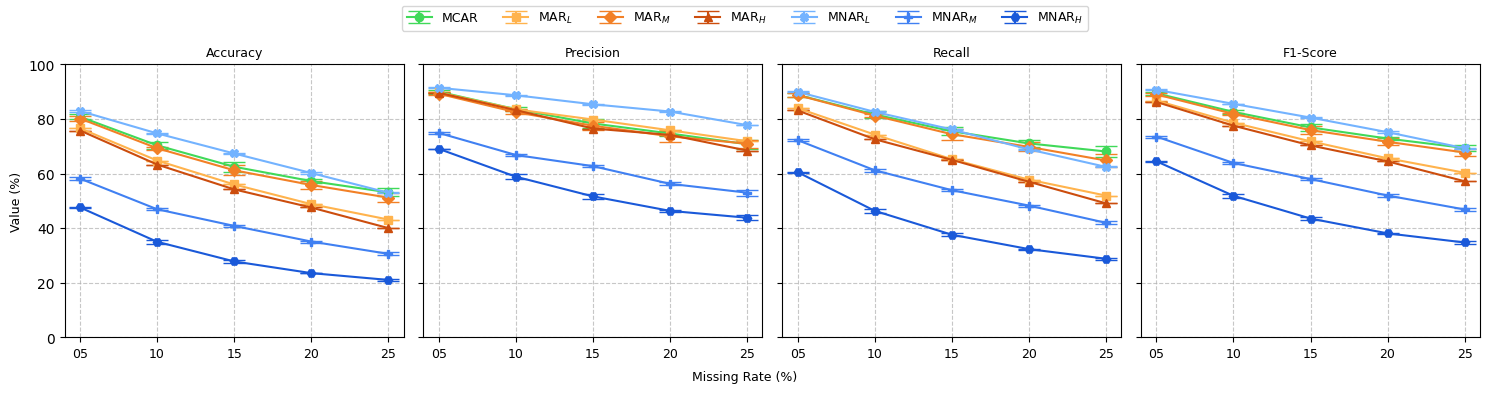

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 🔹 carregar CSV novo
metric_ad = "HROS"
df = pd.read_csv(f'metrics_table_{metric_ad}.csv')

# garantir tipos
df['MR'] = pd.to_numeric(df['MR'])

mr_values_numeric = [int(mr) for mr in mr_values]

fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

metric_map = {
    'Accuracy': 'accuracy',
    'Precision': 'precision',
    'Recall': 'recall',
    'F1_Score': 'f1'
}

for idx, (col_name, metric_label_key) in enumerate(metric_map.items()):

    for mec_name in df['Mechanism'].unique():

        df_mec = df[df['Mechanism'] == mec_name]

        # 🔥 agora agrupando por MR (inclui variação entre i automaticamente)
        grouped = df_mec.groupby('MR')[col_name].agg(['mean', 'std', 'count']).reset_index()

        x = grouped['MR']
        y = grouped['mean']
        #yerr = 1.96 * (grouped['std'] / np.sqrt(grouped['count']))
        yerr = grouped['std']  # já está em % (desvio padrão entre i) --- IGNORE ---

        print(yerr)

        axs[idx].errorbar(
            x,
            y,
            yerr=yerr,
            marker=markers.get(mec_name, 'o'),
            label=mec_labels.get(mec_name, mec_name),
            color=colors.get(mec_name, 'black'),
            capsize=8,
        )

        axs[idx].set_title(metric_labels.get(metric_label_key, metric_label_key), fontsize=9)
        axs[idx].set_ylim(0, 100)
        axs[idx].set_xticks(mr_values_numeric)
        axs[idx].set_xticklabels(mr_values, fontsize=9)
        axs[idx].set_ylabel('Value (%)' if idx == 0 else "", fontsize=9)

for ax in axs:
    ax.grid(True, linestyle='--', alpha=0.7)

fig.supxlabel('Missing Rate (%)', fontsize=9, y=0.05)

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(mechanisms), fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f'Plots/Lineplots/metrics_{metric_ad}.png', dpi=300, bbox_inches='tight')
plt.show()

In [68]:
def metric_lineplot(matrix):

    fig, axs = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

    for idx, metric in enumerate(metric_names):
        for mec_name, table in matrix.metrics_table_mec.items():
            axs[idx].plot(table['MR'], table[metric], marker=markers.get(mec_name, 'o'), label=mec_labels.get(mec_name, mec_name), color=colors.get(mec_name, 'black'))
            axs[idx].set_title(metric, fontsize=9)
            axs[idx].set_ylim(0, 100)
            axs[idx].set_xticks(mr_values)
            axs[idx].set_xticklabels(mr_values, fontsize=9)
            #axs[idx].set_xlabel('Missing Rate (%)')
            axs[idx].set_ylabel('Value (%)' if idx == 0 else "", fontsize=9)
            axs[idx].set_xticklabels(mr_values, fontsize=9)
            axs[idx].grid(True)

    fig.supxlabel('Missing Rate (%)', fontsize=9, y=0.05)

    handles, labels = axs[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(mechanisms), fontsize=9)
    for ax in axs:
        ax.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.savefig(f'Plots/Lineplots/metrics_{matrix.metric}.eps', dpi=300, bbox_inches='tight')
    plt.show()


def pr_lineplot(matrix):
    plt.figure(figsize=(8, 6))

    # Add text annotations for first and last points of MNAR_l
    mnar_l_table = matrix.metrics_table_mec['MNAR_h']
    
    
    plt.text(mnar_l_table['Recall'].iloc[0] - 2.8, mnar_l_table['Precision'].iloc[0] + 1.8,
             f"MR: {mnar_l_table['MR'].iloc[0]}%", fontsize=7, va='center', color=colors.get('MNAR_c', 'black'))
    plt.text(mnar_l_table['Recall'].iloc[-1] - 4, mnar_l_table['Precision'].iloc[-1] + 1.8, 
             f"MR: {mnar_l_table['MR'].iloc[-1]}%", fontsize=7, va='center', color=colors.get('MNAR_c', 'black'))

    for mec_name, table in matrix.metrics_table_mec.items():
        plt.plot(table['Recall'], table['Precision'], marker=markers.get(mec_name, 'o'), 
                    label=mec_labels.get(mec_name, mec_name), color=colors.get(mec_name, 'black'))


    plt.xlabel('Recall (%)', fontsize=8)
    plt.xticks(fontsize=8)
    plt.ylabel('Precision (%)', fontsize=8)
    plt.yticks(fontsize=8)
    plt.xlim(20, 100)
    plt.ylim(40, 100)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='', loc='upper left', fontsize=9)
    plt.savefig(f'Plots/Lineplots/pr_plot_{matrix.metric}.eps', dpi=300, bbox_inches='tight')
    plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


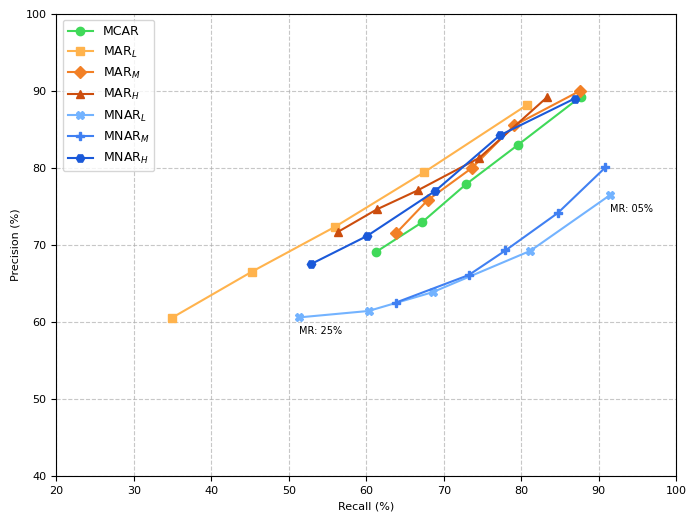

In [27]:
pr_lineplot(results_rhr)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


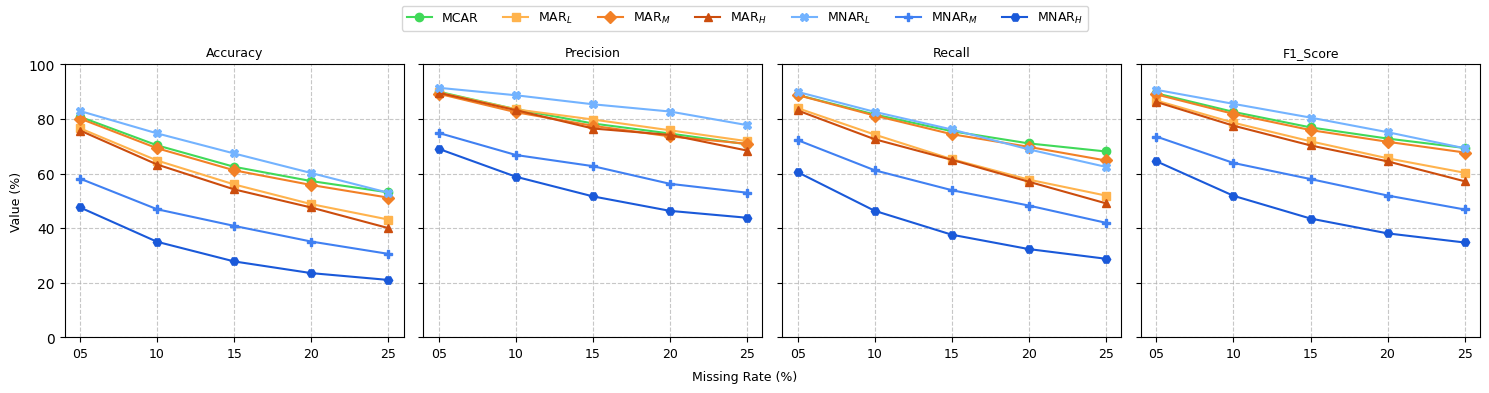

In [69]:
metric_lineplot(results_rhr)


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


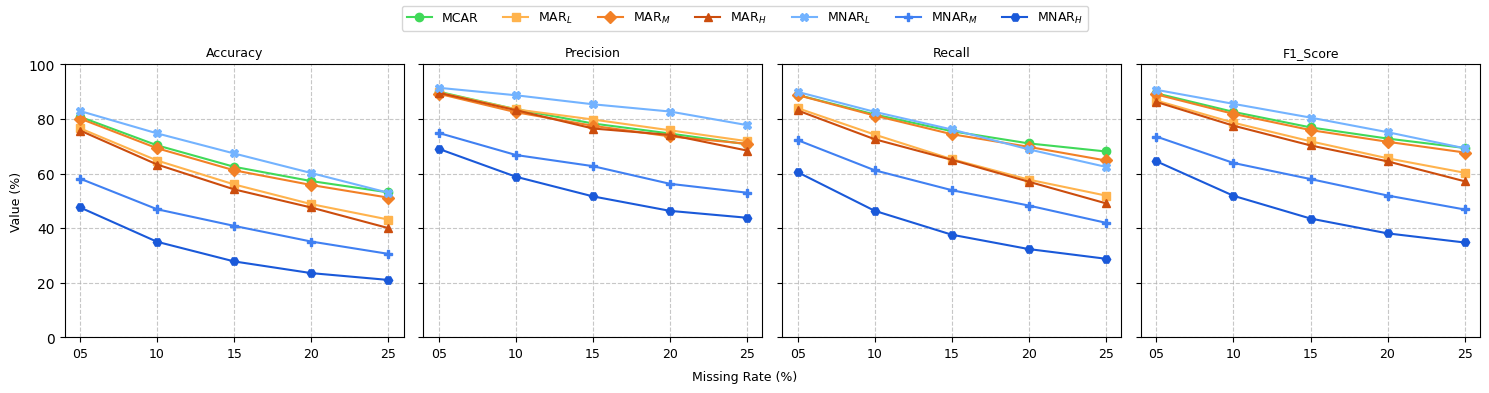

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


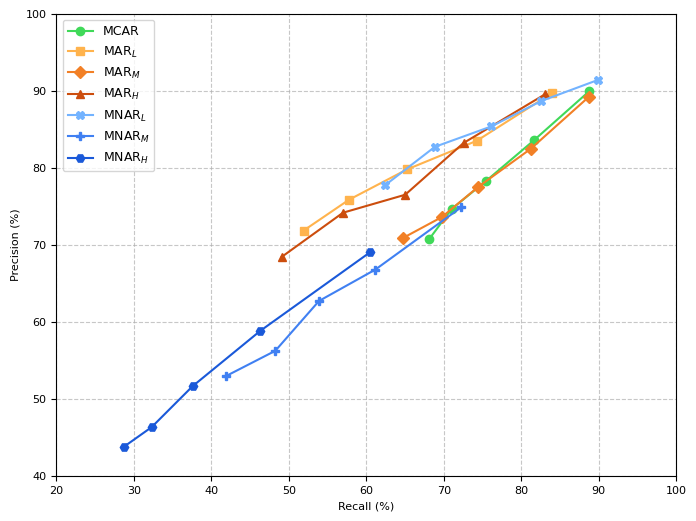

In [ ]:
metric_lineplot(results_hros)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


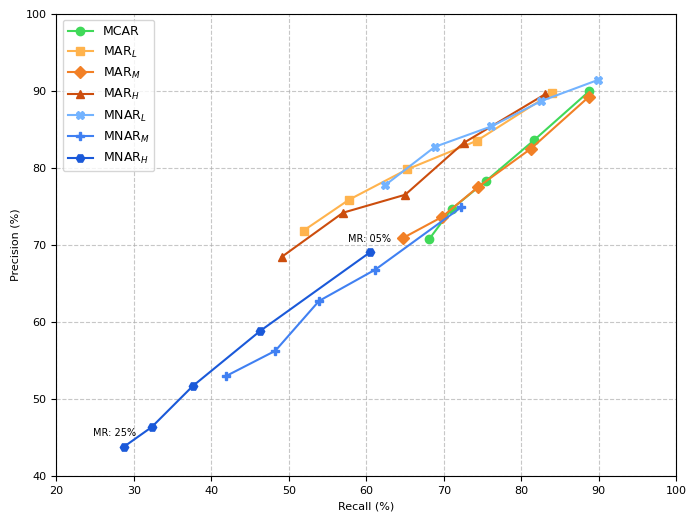

In [17]:
pr_lineplot(results_hros)

In [33]:
import pandas as pd

ad_metric = "HROS"
df = pd.read_csv(f"metrics_table_{ad_metric}.csv")

mechanisms = df['Mechanism'].unique()
mec_labels = {}
for mec in mechanisms:
    if "_" in mec:
        base, sub = mec.split("_", 1)
        mec_labels[mec] = rf"{base}$_{{{sub.upper()}}}$"
    else:
        mec_labels[mec] = mec

df['Mechanism'] = df['Mechanism'].map(mec_labels)
df = df.rename(columns={'F1_Score': 'F1-Score'})
df['F1_Score'] = df['F1-Score']

dfs = {}
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    df_crit= df.groupby(['Mechanism', 'MR', "i"])[metric].mean().reset_index()
    df_crit['dataset_name'] = df_crit['MR'].astype(str) + '_' + df_crit['i'].astype(str)
    df_crit = df_crit.drop(columns=['MR', 'i'])
    df_crit = df_crit.rename(columns={'Mechanism': 'classifier_name'})
    df_crit = df_crit.rename(columns={metric: 'accuracy'})
    dfs[metric] = df_crit[['classifier_name', 'dataset_name', 'accuracy']]
    print(dfs[metric].shape)
    print(dfs[metric].head())

(175, 3)
  classifier_name dataset_name   accuracy
0       MAR$_{H}$          5_1  75.757576
1       MAR$_{H}$          5_2  75.757576
2       MAR$_{H}$          5_3  75.757576
3       MAR$_{H}$          5_4  75.757576
4       MAR$_{H}$          5_5  75.757576
(175, 3)
  classifier_name dataset_name   accuracy
0       MAR$_{H}$          5_1  89.558759
1       MAR$_{H}$          5_2  89.558759
2       MAR$_{H}$          5_3  89.558759
3       MAR$_{H}$          5_4  89.558759
4       MAR$_{H}$          5_5  89.558759
(175, 3)
  classifier_name dataset_name   accuracy
0       MAR$_{H}$          5_1  83.096879
1       MAR$_{H}$          5_2  83.096879
2       MAR$_{H}$          5_3  83.096879
3       MAR$_{H}$          5_4  83.096879
4       MAR$_{H}$          5_5  83.096879
(175, 3)
  classifier_name dataset_name   accuracy
0       MAR$_{H}$          5_1  86.206897
1       MAR$_{H}$          5_2  86.206897
2       MAR$_{H}$          5_3  86.206897
3       MAR$_{H}$          5_4  86.20689

In [34]:
from cd_diagram import draw_cd_diagram

for mec, df_mec in dfs.items():
    try:
        draw_cd_diagram(
            df_perf=df_mec,
            title=f"{mec_labels.get(mec, mec)}",
            labels=False,
            save_path=f"Plots/CD_Diagrams/MS/CD-{ad_metric}-{mec}.png"
        )
    except Exception as e:
        print(f"Error processing {mec}: {e}")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following 

['MAR$_{H}$' 'MAR$_{L}$' 'MAR$_{M}$' 'MCAR' 'MNAR$_{H}$' 'MNAR$_{L}$'
 'MNAR$_{M}$']
MAR$_{H}$      0.0
MAR$_{L}$      0.0
MAR$_{M}$      1.0
MCAR           2.0
MNAR$_{H}$     0.0
MNAR$_{L}$    22.0
MNAR$_{M}$     0.0
dtype: float64
MNAR$_{H}$    7.00
MNAR$_{M}$    6.00
MAR$_{H}$     5.00
MAR$_{L}$     4.00
MAR$_{M}$     2.72
MCAR          2.16
MNAR$_{L}$    1.12
dtype: float64
('MAR$_{H}$', 'MAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MCAR', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MCAR', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$'

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif'

['MAR$_{H}$' 'MAR$_{L}$' 'MAR$_{M}$' 'MCAR' 'MNAR$_{H}$' 'MNAR$_{L}$'
 'MNAR$_{M}$']
MAR$_{H}$      0.0
MAR$_{L}$      0.0
MAR$_{M}$      0.0
MCAR           0.0
MNAR$_{H}$     0.0
MNAR$_{L}$    25.0
MNAR$_{M}$     0.0
dtype: float64
MNAR$_{H}$    7.00
MNAR$_{M}$    6.00
MAR$_{H}$     4.24
MAR$_{M}$     4.08
MCAR          3.04
MAR$_{L}$     2.64
MNAR$_{L}$    1.00
dtype: float64
('MAR$_{H}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{M}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{M}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{M}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif'

['MAR$_{H}$' 'MAR$_{L}$' 'MAR$_{M}$' 'MCAR' 'MNAR$_{H}$' 'MNAR$_{L}$'
 'MNAR$_{M}$']
MAR$_{H}$      0.0
MAR$_{L}$      0.0
MAR$_{M}$      1.0
MCAR          13.0
MNAR$_{H}$     0.0
MNAR$_{L}$    11.0
MNAR$_{M}$     0.0
dtype: float64
MNAR$_{H}$    7.00
MNAR$_{M}$    6.00
MAR$_{H}$     5.00
MAR$_{L}$     4.00
MAR$_{M}$     2.32
MNAR$_{L}$    1.88
MCAR          1.80
dtype: float64
('MAR$_{H}$', 'MCAR', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MCAR', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MCAR', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MNAR$_{H}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MAR$_{L}$', np.float64(1.1216142290978693e-05), True)
('MAR$_{L}$', 'MNAR$_{L}$', np.float64(1.2245823522183564e-05), True)
('MAR$_{M}$', 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif'

['MAR$_{H}$' 'MAR$_{L}$' 'MAR$_{M}$' 'MCAR' 'MNAR$_{H}$' 'MNAR$_{L}$'
 'MNAR$_{M}$']
MAR$_{H}$      0.0
MAR$_{L}$      0.0
MAR$_{M}$      1.0
MCAR           2.0
MNAR$_{H}$     0.0
MNAR$_{L}$    22.0
MNAR$_{M}$     0.0
dtype: float64
MNAR$_{H}$    7.00
MNAR$_{M}$    6.00
MAR$_{H}$     5.00
MAR$_{L}$     4.00
MAR$_{M}$     2.72
MCAR          2.16
MNAR$_{L}$    1.12
dtype: float64
('MAR$_{H}$', 'MAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MCAR', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{H}$', 'MNAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MAR$_{M}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MCAR', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{H}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$', 'MNAR$_{L}$', np.float64(5.960464477539063e-08), True)
('MAR$_{L}$'

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif'

In [35]:
from PIL import Image

# List of CD diagram images in order
image_files = [f"Plots/CD_Diagrams/MS/CD-{ad_metric}-{mec}.png" for mec in ['Accuracy', 'Precision', 'Recall', 'F1-Score']]

# Open all images
images = [Image.open(img_file) for img_file in image_files]

# Get dimensions
widths, heights = zip(*(img.size for img in images))

# Calculate total height and max width
total_height = sum(heights)
max_width = max(widths)

# Create new image with combined height
combined_image = Image.new('RGB', (max_width, total_height), 'white')

# Paste images one below the other
y_offset = 0
for img in images:
    combined_image.paste(img, (0, y_offset))
    y_offset += img.size[1]

# Save combined image
combined_image.save(f'Plots/CD_Diagrams/MS/CD-{ad_metric}-all.png')
print(f"Combined image saved as CD-{ad_metric}-all.png")

Combined image saved as CD-HROS-all.png
